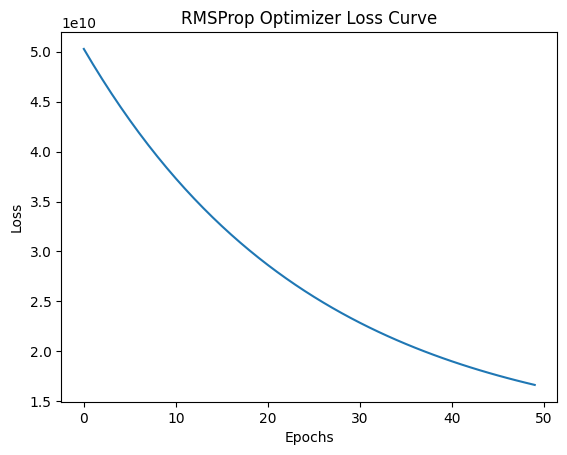

In [1]:
import sys
sys.path.append("..")

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from src.optimizers import OptimizerEngine

df = pd.read_csv("data/final_prepared.csv")
X = df.drop(columns=["median_house_value"]).values
y = df["median_house_value"].values

w = np.zeros(X.shape[1]); b = 0
optimizer = OptimizerEngine(optimizer_type="rmsprop", learning_rate=0.01, epochs=50)

losses = []
for epoch in range(optimizer.epochs):
    y_pred = X.dot(w) + b
    grad_w = (2/X.shape[0]) * X.T.dot(y_pred - y)
    grad_b = (2/X.shape[0]) * np.sum(y_pred - y)
    w = optimizer.update_params(w, grad_w, epoch)
    b = b - optimizer.lr * grad_b
    losses.append(np.mean((y - y_pred)**2))

plt.plot(losses); plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("RMSProp Optimizer Loss Curve"); plt.show()


In [ ]:
np.save("../results/rmsprop_loss.npy", losses)
